# Handwritten Digit Recognition with Deep Learning  
### A Comparison of Dense Neural Networks and Convolutional Neural Networks

## Project Overview

Handwritten digit recognition is one of the classic problems in computer vision and machine learning. It involves automatically identifying numerical digits from images, a task that has applications in document processing, postal code recognition, bank check reading, and automated data entry systems.

In this project, we develop and evaluate deep learning models for classifying handwritten digits using the **MNIST dataset**, one of the most widely used benchmarks in image recognition.

The objective is not only to build an accurate classifier but also to **compare two different neural network architectures**:

- **Dense Neural Network (DNN)** — a fully connected architecture that treats images as flattened vectors.
- **Convolutional Neural Network (CNN)** — a deep learning architecture designed specifically for image data that can capture spatial patterns and local features.

By comparing these two approaches, the project demonstrates the advantages of convolutional layers in extracting hierarchical visual features from images.

---

## Dataset: MNIST

The **MNIST (Modified National Institute of Standards and Technology) dataset** contains grayscale images of handwritten digits from **0 to 9**.

Key characteristics of the dataset:

- **70,000 total images**
- **60,000 training samples**
- **10,000 testing samples**
- Image size: **28 × 28 pixels**
- **10 digit classes (0–9)**

Each image represents a single handwritten digit centered within a 28×28 grayscale frame.

MNIST remains a fundamental benchmark for evaluating machine learning and deep learning algorithms in image classification tasks.

---

## Project Objectives

This project aims to:

- Explore and preprocess the MNIST dataset
- Develop a **Dense Neural Network baseline model**
- Build a **Convolutional Neural Network for image classification**
- Compare the performance of the two architectures
- Analyze classification performance using evaluation metrics and visualizations

---

## Expected Outcome

Through this analysis, we demonstrate how **Convolutional Neural Networks significantly outperform traditional fully connected networks in image recognition tasks**, highlighting the importance of spatial feature extraction in computer vision.

The final model achieves **high classification accuracy on the MNIST test dataset**, illustrating the effectiveness of deep learning approaches for handwritten digit recognition.

In [1]:
# ============================================
# Block 2 — Import Libraries and Set Up Environment
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix, classification_report

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Display settings
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print("Libraries imported successfully.")
print("TensorFlow version:", tf.__version__)

Libraries imported successfully.
TensorFlow version: 2.19.0


In [17]:
# ============================================
# Figure Export Setup
# ============================================

import os

os.makedirs("images", exist_ok=True)
print("Image export folder is ready.")

Image export folder is ready.


In [2]:
# ============================================
# Block 3 — Load the MNIST Dataset
# ============================================

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Display dataset structure
print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

# Check unique classes
print("\nUnique classes in dataset:", np.unique(y_train))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)

Unique classes in dataset: [0 1 2 3 4 5 6 7 8 9]


## Exploratory Data Analysis

Before training neural networks, it is important to visually inspect the dataset. In image classification tasks, sample visualization helps verify that the images are loaded correctly, confirms the visual variability of the classes, and provides intuition about the recognition challenge.

The MNIST dataset consists of grayscale images of handwritten digits from **0 to 9**, each stored as a **28 × 28** pixel image. Although the images are relatively small and centered, handwriting style, thickness, and shape vary across observations.

In this section, we display a sample of handwritten digits from the training set to better understand the visual structure of the dataset.

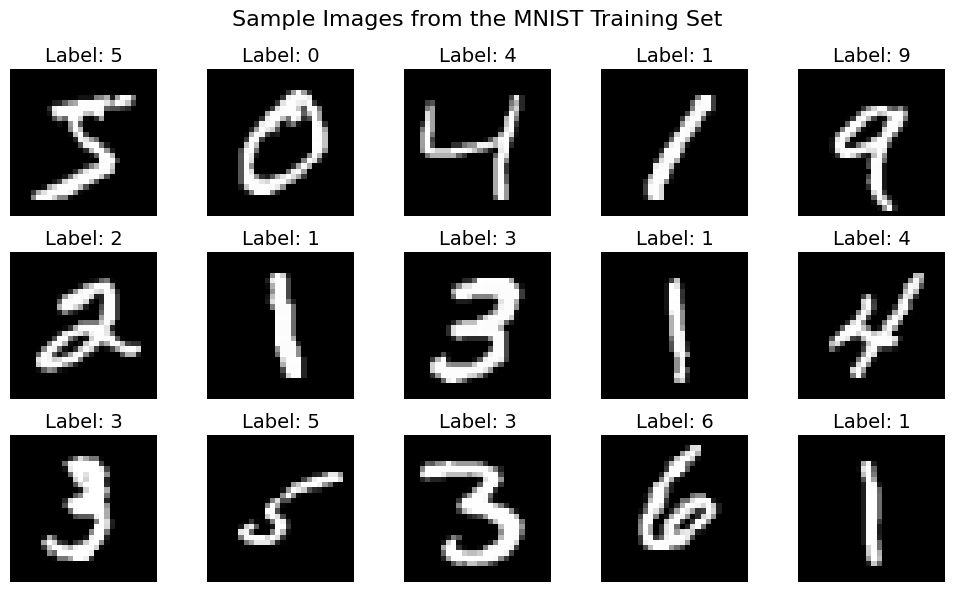

In [19]:
# ============================================
# Block 4 — Visualize Sample Digits
# ============================================

fig, axes = plt.subplots(3, 5, figsize=(10, 6))
axes = axes.ravel()

for i in range(15):
    axes[i].imshow(X_train[i], cmap="gray")
    axes[i].set_title(f"Label: {y_train[i]}")
    axes[i].axis("off")

plt.suptitle("Sample Images from the MNIST Training Set", fontsize=16)
plt.tight_layout()
plt.savefig("images/sample_digits.png", dpi=300, bbox_inches="tight")
plt.show()

## Class Distribution

A useful step in classification projects is checking the distribution of target classes. Class balance affects how reliably a model can learn each category and helps determine whether accuracy alone is an adequate evaluation metric.

For the MNIST dataset, we expect the digit classes to be relatively well balanced, which makes it a suitable benchmark for comparing model architectures. The chart below shows the number of images available for each digit in the training set.

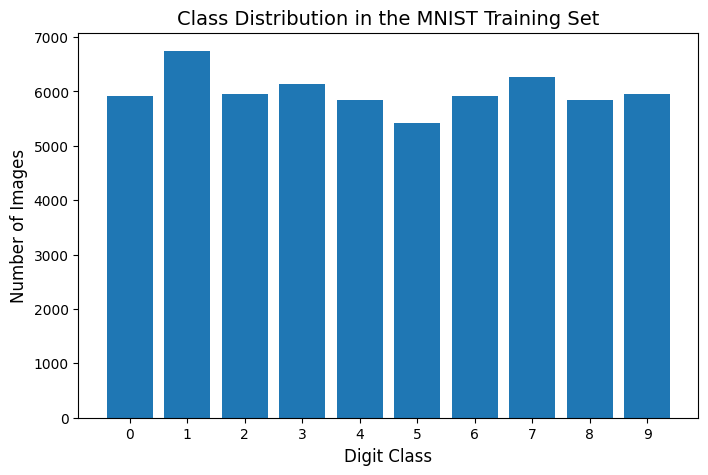

Class counts:
0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64


In [20]:
# ============================================
# Block 5 — Visualize Class Distribution
# ============================================

class_counts = pd.Series(y_train).value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(class_counts.index, class_counts.values)
plt.title("Class Distribution in the MNIST Training Set")
plt.xlabel("Digit Class")
plt.ylabel("Number of Images")
plt.xticks(class_counts.index)
plt.savefig("images/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Class counts:")
print(class_counts)

### Interpretation

The class distribution appears relatively balanced across the ten digit categories. Each class contains approximately **5,400–6,700 samples**, which indicates that no digit dominates the dataset.

This balanced distribution is advantageous for model training because it reduces the risk of bias toward specific classes. As a result, **overall accuracy becomes a reliable evaluation metric**, and the models should be able to learn meaningful representations for all digits without requiring special techniques for class imbalance.

## Data Preprocessing

Neural networks require numerical inputs in a format suitable for efficient learning. Since MNIST images are stored as integer pixel values from **0 to 255**, the first step is to normalize them to the **[0, 1]** range. This improves training stability and helps the optimization process converge more effectively.

Because this project compares two different architectures, preprocessing must be handled in two ways:

- For the **Dense Neural Network (DNN)**, each image is flattened into a one-dimensional vector of length **784**.
- For the **Convolutional Neural Network (CNN)**, each image is kept in its two-dimensional structure and reshaped to include a channel dimension: **28 × 28 × 1**.

The target labels are also converted into **one-hot encoded vectors**, which is the standard representation for multi-class classification problems.

In [5]:
# ============================================
# Block 6 — Data Preprocessing
# ============================================

# Normalize pixel values to the [0, 1] range
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

# Prepare data for the Dense Neural Network (flatten images)
X_train_dnn = X_train_norm.reshape(-1, 28 * 28)
X_test_dnn = X_test_norm.reshape(-1, 28 * 28)

# Prepare data for the Convolutional Neural Network (add channel dimension)
X_train_cnn = X_train_norm.reshape(-1, 28, 28, 1)
X_test_cnn = X_test_norm.reshape(-1, 28, 28, 1)

# One-hot encode target labels
y_train_encoded = to_categorical(y_train, num_classes=10)
y_test_encoded = to_categorical(y_test, num_classes=10)

# Display resulting shapes
print("Normalized training data shape:", X_train_norm.shape)
print("Normalized test data shape:", X_test_norm.shape)

print("\nDNN input shape:", X_train_dnn.shape)
print("CNN input shape:", X_train_cnn.shape)

print("\nEncoded training labels shape:", y_train_encoded.shape)
print("Encoded test labels shape:", y_test_encoded.shape)

Normalized training data shape: (60000, 28, 28)
Normalized test data shape: (10000, 28, 28)

DNN input shape: (60000, 784)
CNN input shape: (60000, 28, 28, 1)

Encoded training labels shape: (60000, 10)
Encoded test labels shape: (10000, 10)


## Baseline Model: Dense Neural Network

As a baseline, we first train a **Dense Neural Network (DNN)** on the MNIST dataset. In this architecture, each image is flattened into a one-dimensional vector of **784 input features**, which is then passed through fully connected layers.

This approach is effective for general pattern recognition, but it has an important limitation for image data: flattening removes the original **spatial structure** of the image. As a result, the model cannot explicitly exploit local visual patterns such as edges, curves, and strokes.

Even so, a DNN provides a strong reference point for comparison and helps illustrate why **Convolutional Neural Networks are better suited for image classification tasks**.

In [6]:
# ============================================
# Block 7 — Build and Train the Dense Neural Network
# ============================================

dnn_model = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(800, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(400, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(10, activation="softmax")
])

dnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

dnn_model.summary()

history_dnn = dnn_model.fit(
    X_train_dnn,
    y_train_encoded,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 800)            │       628,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 800)            │         3,200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 400)            │       320,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 400)            │         1,600 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         4,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 957,210 (3.65 MB)

 Trainable params: 954,810 (3.64 MB)

 Non-trainable params: 2,400 (9.38 KB)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.8783 - loss: 0.4080 - val_accuracy: 0.9735 - val_loss: 0.0908
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9634 - loss: 0.1175 - val_accuracy: 0.9795 - val_loss: 0.0729
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9727 - loss: 0.0859 - val_accuracy: 0.9753 - val_loss: 0.0794
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9786 - loss: 0.0656 - val_accuracy: 0.9818 - val_loss: 0.0679
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9808 - loss: 0.0578 - val_accuracy: 0.9828 - val_loss: 0.0636
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9839 - loss: 0.0469 - val_accuracy: 0.9810 - val_loss: 0.0709
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9847 - loss: 0.0446 - val_accuracy: 0.9820 - val_loss: 0.0709
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9850 - loss: 0.0434 - val_ac

## Evaluation of the Dense Neural Network

After training the Dense Neural Network, we evaluate its performance on the **test dataset**, which contains images the model has not seen during training.

In addition to reporting the final test accuracy, we also visualize the **training and validation learning curves**. These plots help assess whether the model is learning effectively and whether signs of overfitting appear during training.

In [7]:
# ============================================
# Block 8 — Evaluate the Dense Neural Network
# ============================================

test_loss_dnn, test_acc_dnn = dnn_model.evaluate(X_test_dnn, y_test_encoded, verbose=0)

print("DNN Test Accuracy:", test_acc_dnn)
print("DNN Test Loss:", test_loss_dnn)

DNN Test Accuracy: 0.9794999957084656
DNN Test Loss: 0.07042187452316284


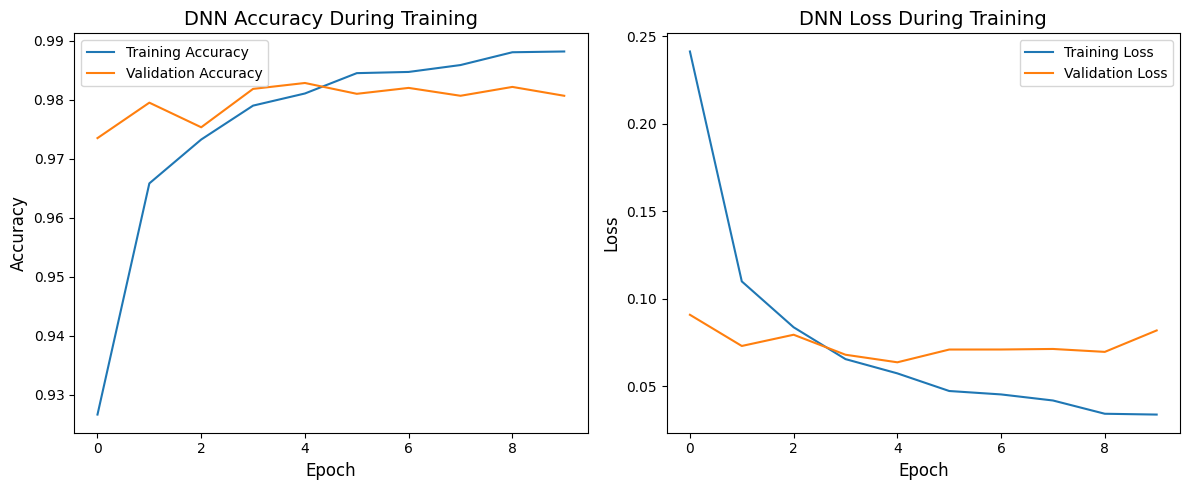

In [21]:
# ============================================
# Block 8 — DNN Learning Curves
# ============================================

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_dnn.history["accuracy"], label="Training Accuracy")
plt.plot(history_dnn.history["val_accuracy"], label="Validation Accuracy")
plt.title("DNN Accuracy During Training")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_dnn.history["loss"], label="Training Loss")
plt.plot(history_dnn.history["val_loss"], label="Validation Loss")
plt.title("DNN Loss During Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig("images/dnn_training_curves.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation of Training Results

The Dense Neural Network achieves a **test accuracy of approximately 97.9%**, demonstrating strong performance on the MNIST digit classification task.

The training curves show that both training and validation accuracy increase rapidly during the first few epochs and stabilize near the end of training. This indicates that the model learns meaningful representations of the digit images.

The validation loss remains relatively stable and does not diverge significantly from the training loss, suggesting that **overfitting is limited**. This is likely due to the use of **Dropout and Batch Normalization**, which help regularize the network.

Although the Dense Neural Network performs well, it processes images as flattened vectors and therefore **cannot explicitly exploit the spatial relationships between pixels**. This limitation motivates the use of **Convolutional Neural Networks**, which are specifically designed to capture local visual patterns such as edges, curves, and shapes.

## Convolutional Neural Network (CNN)

Unlike Dense Neural Networks, **Convolutional Neural Networks (CNNs)** are specifically designed for image data. Instead of flattening the image at the start, CNNs preserve the two-dimensional structure of the input and learn spatial patterns directly from pixel neighborhoods.

A CNN typically uses:

- **Convolutional layers** to detect local features such as edges, curves, and strokes
- **Pooling layers** to reduce spatial dimensions and retain the most important information
- **Dropout layers** to reduce overfitting
- **Dense layers** at the end for final classification

This architecture is especially effective for handwritten digit recognition because the meaning of a digit depends strongly on its visual structure. By preserving spatial information, CNNs are able to learn richer and more robust feature representations than fully connected networks.

In [9]:
# ============================================
# Block 9 — Build and Train the CNN
# ============================================

cnn_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(10, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

history_cnn = cnn_model.fit(
    X_train_cnn,
    y_train_encoded,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,882 (4.58 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 85s 197ms/step - accuracy: 0.8364 - loss: 0.5128 - val_accuracy: 0.9847 - val_loss: 0.0513
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 140s 192ms/step - accuracy: 0.9707 - loss: 0.0998 - val_accuracy: 0.9873 - val_loss: 0.0424
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 192ms/step - accuracy: 0.9775 - loss: 0.0726 - val_accuracy: 0.9895 - val_loss: 0.0390
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 196ms/step - accuracy: 0.9824 - loss: 0.0564 - val_accuracy: 0.9918 - val_loss: 0.0352
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 142s 195ms/step - accuracy: 0.9868 - loss: 0.0459 - val_accuracy: 0.9910 - val_loss: 0.0354
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 195ms/step - accuracy: 0.9863 - loss: 0.0432 - val_accuracy: 0.9905 - val_loss: 0.0383
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 140s 191ms/step - accuracy: 0.9893 - loss: 0.0360 - val_accuracy: 0.9902 - val_loss: 0.0425
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 84s 195ms/step - accuracy: 0.9888 - loss

## Evaluation of the Convolutional Neural Network

After training the Convolutional Neural Network, we evaluate its performance on the **test dataset** to measure how well the model generalizes to unseen images.

In addition to reporting the final test accuracy, we visualize the **training and validation learning curves** to assess training stability and detect possible overfitting.

In [10]:
# ============================================
# Block 10 — Evaluate the CNN
# ============================================

test_loss_cnn, test_acc_cnn = cnn_model.evaluate(X_test_cnn, y_test_encoded, verbose=0)

print("CNN Test Accuracy:", test_acc_cnn)
print("CNN Test Loss:", test_loss_cnn)

CNN Test Accuracy: 0.9912999868392944
CNN Test Loss: 0.029672609642148018


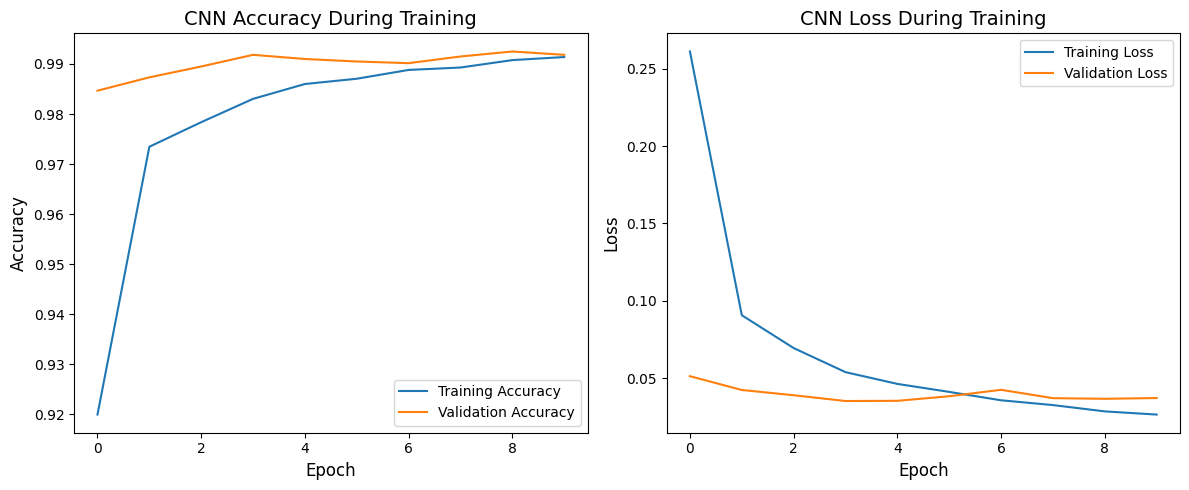

In [22]:
# ============================================
# Block 10 — CNN Learning Curves
# ============================================

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history["accuracy"], label="Training Accuracy")
plt.plot(history_cnn.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Accuracy During Training")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history["loss"], label="Training Loss")
plt.plot(history_cnn.history["val_loss"], label="Validation Loss")
plt.title("CNN Loss During Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig("images/cnn_training_curves.png", dpi=300, bbox_inches="tight")
plt.show()

## Model Comparison

To better understand the performance difference between the two approaches, we compare the results of the Dense Neural Network and the Convolutional Neural Network.

While both models achieve high accuracy on the MNIST dataset, the CNN consistently performs better because it preserves the spatial structure of the input images and learns hierarchical visual features.

The table below summarizes the performance of both models on the test dataset.

In [12]:
# ============================================
# Block 11 — Model Comparison
# ============================================

import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Dense Neural Network", "Convolutional Neural Network"],
    "Test Accuracy": [test_acc_dnn, test_acc_cnn],
    "Test Loss": [test_loss_dnn, test_loss_cnn]
})

comparison

,Model,Test Accuracy,Test Loss
0,Dense Neural Network,0.9795,0.070422
1,Convolutional Neural Network,0.9913,0.029673


In [25]:
comparison.to_csv("images/model_comparison.csv", index=False)
print("Model comparison table saved.")

Model comparison table saved.


## Confusion Matrix

To better understand the model’s classification performance, we analyze the **confusion matrix** for the Convolutional Neural Network.

A confusion matrix shows how often each digit class is predicted correctly or confused with other digits. This allows us to identify systematic errors and understand which digits may be visually similar.

Ideally, most predictions should lie along the **main diagonal**, indicating correct classifications.

In [13]:
# ============================================
# Block 12 — Confusion Matrix
# ============================================

# Generate predictions for the test set
y_pred_probs = cnn_model.predict(X_test_cnn)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


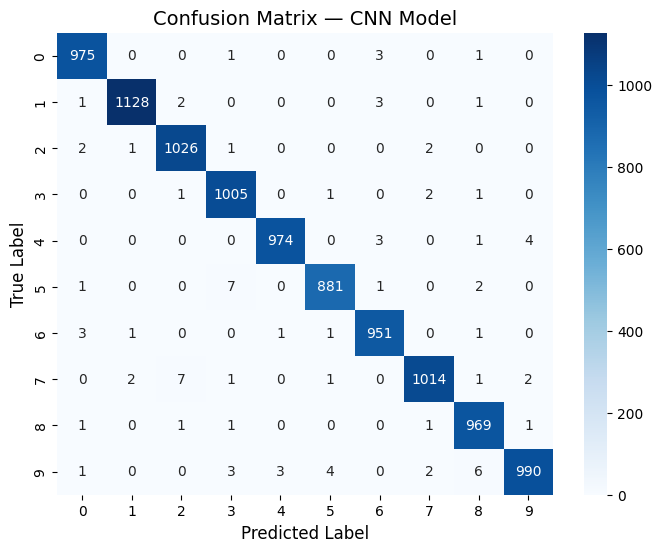

In [23]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — CNN Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig("images/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      0.99      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



### Interpretation of Classification Performance

The confusion matrix shows that the vast majority of predictions lie along the **main diagonal**, indicating that the Convolutional Neural Network correctly classifies most handwritten digits.

The classification report confirms this observation: all classes achieve **precision, recall, and F1-scores close to 0.99**, demonstrating consistent performance across all digit categories.

A small number of misclassifications occur for visually similar digits. For example, digits such as **9 and 4** or **5 and 3** may occasionally be confused due to similarities in handwriting style. However, these errors are relatively rare and do not significantly affect the overall performance of the model.

Overall, the results indicate that the CNN has learned robust visual representations of handwritten digits and generalizes effectively to unseen data.

## Example Predictions

To further illustrate the performance of the Convolutional Neural Network, we visualize several predictions made on the test dataset.

Each image below shows a handwritten digit along with the **true label** and the **predicted label** produced by the CNN model.

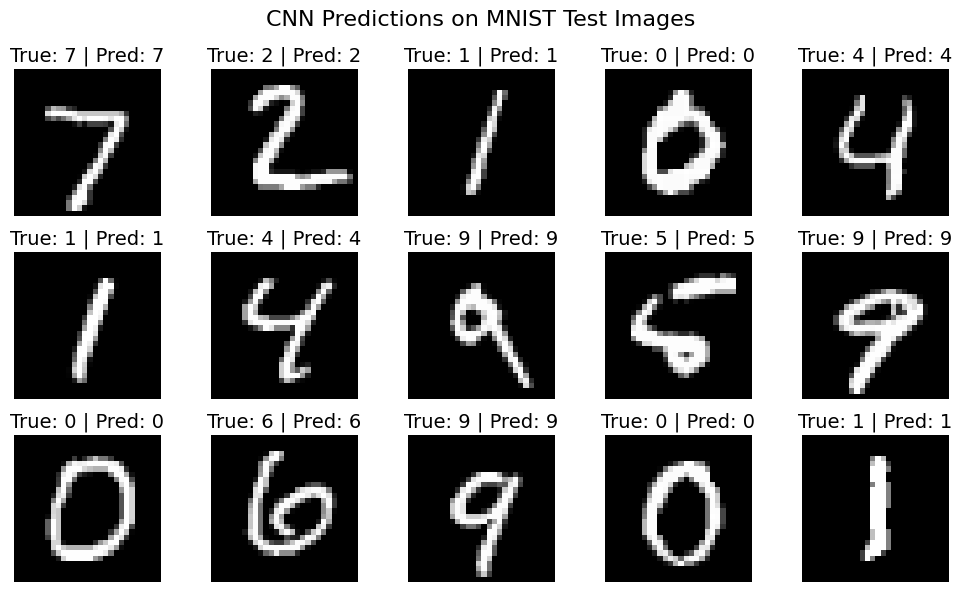

In [24]:
# ============================================
# Block 13 — Visualize Example Predictions
# ============================================

fig, axes = plt.subplots(3, 5, figsize=(10, 6))
axes = axes.ravel()

for i in range(15):
    axes[i].imshow(X_test[i], cmap="gray")
    axes[i].set_title(f"True: {y_true[i]} | Pred: {y_pred[i]}")
    axes[i].axis("off")

plt.suptitle("CNN Predictions on MNIST Test Images", fontsize=16)
plt.tight_layout()
plt.savefig("images/cnn_predictions.png", dpi=300, bbox_inches="tight")
plt.show()

## Conclusion

In this project, we explored handwritten digit recognition using the **MNIST dataset**, a widely used benchmark for image classification tasks in machine learning and deep learning.

The analysis compared two different neural network architectures:

- **Dense Neural Network (DNN)** — a fully connected model that treats images as flattened vectors
- **Convolutional Neural Network (CNN)** — a model specifically designed to process spatial image data

Both models achieved high classification accuracy, demonstrating the effectiveness of neural networks for pattern recognition tasks. However, the results clearly show that the **Convolutional Neural Network outperforms the Dense Neural Network**.

### Key Findings

- The **Dense Neural Network** achieved approximately **97.9% test accuracy**, showing strong baseline performance.
- The **Convolutional Neural Network** achieved approximately **99.1% test accuracy**, significantly improving classification performance.
- CNNs perform better because they **preserve spatial relationships between pixels** and learn hierarchical visual features such as edges, strokes, and digit shapes.

### Model Evaluation

Additional evaluation using a **confusion matrix and classification report** showed that the CNN achieves high precision, recall, and F1-scores across all digit classes, indicating consistent performance and strong generalization.

### Final Insight

This project highlights the importance of choosing an appropriate model architecture for a given data type. While fully connected networks can perform well, **Convolutional Neural Networks are better suited for image recognition tasks** because they can effectively capture spatial patterns within images.

Overall, the results demonstrate how deep learning models — particularly CNNs — provide powerful tools for solving computer vision problems such as handwritten digit recognition.